In [ ]:
# STEGANOGRAFI BERBASIS MEDIAN
# Embedding & Ekstraksi bit pada gambar grayscale

import numpy as np
import matplotlib.pyplot as plt
import math
import os
import random
import pandas as pd
from PIL import Image
from io import BytesIO
from skimage.metrics import structural_similarity as ssim_func
from google.colab import files


Mounted at /content/drive


Retrieving folder contents


Processing file 1KT2ee8uh-ZQCr-iGM1cAHTiq-kGDTWvv Abdomal.jpg
Processing file 1YYKAhoIAbY79uhc40paoozVqcB-uWrtF Baboon.tiff
Processing file 1rTHZgIfcvkx0lbD_b_ncESio-o7YvhOe Boat.tiff
Processing file 1iqicHwJIUOUGvCVZmUpDHgKN_hDvzd3L Chest.jpg
Processing file 1irxjiu-DUw3HKX5SZP2k1Ssi-uijXK_D Elaine.tiff
Processing file 156xJkK90LWHTkR4m0gwF4q3jLLh8jX69 Hand.jpg
Processing file 1QkLhCCjdEkRc_5FZSaw3d9KnhSmIbg9S Head.jpg
Processing file 1VU67zir8KlmBBaubnxqzCkjUbuI_hTLh Leg.jpg
Processing file 1jIm6jZHWoDe2bjelKT1EE431W7e6pyli Pepper.tiff


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1KT2ee8uh-ZQCr-iGM1cAHTiq-kGDTWvv
To: /content/Dataset/Abdomal.jpg
100%|██████████| 29.5k/29.5k [00:00<00:00, 38.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YYKAhoIAbY79uhc40paoozVqcB-uWrtF
To: /content/Dataset/Baboon.tiff
100%|██████████| 265k/265k [00:00<00:00, 5.04MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rTHZgIfcvkx0lbD_b_ncESio-o7YvhOe
To: /content/Dataset/Boat.tiff
100%|██████████| 262k/262k [00:00<00:00, 3.65MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iqicHwJIUOUGvCVZmUpDHgKN_hDvzd3L
To: /content/Dataset/Chest.jpg
100%|██████████| 22.3k/22.3k [00:00<00:00, 33.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1irxjiu-DUw3HKX5SZP2k1Ssi-uijXK_D
To: /content/Dataset/Elaine.tiff
100%|██████████| 262k/262k [00:00<00:00, 3.99MB/s]
Downloading...
From: https://drive.google.com

✅ Abdomal.jpg          | Shape: (256, 256) | Min/Max: 0/255
✅ Baboon.tiff          | Shape: (256, 256) | Min/Max: 10/213
✅ Boat.tiff            | Shape: (256, 256) | Min/Max: 6/247
✅ Chest.jpg            | Shape: (256, 256) | Min/Max: 0/255
✅ Elaine.tiff          | Shape: (256, 256) | Min/Max: 22/242
✅ Hand.jpg             | Shape: (256, 256) | Min/Max: 11/252
✅ Head.jpg             | Shape: (256, 256) | Min/Max: 0/255
✅ Leg.jpg              | Shape: (256, 256) | Min/Max: 0/255
✅ Pepper.tiff          | Shape: (256, 256) | Min/Max: 2/226

Total gambar loaded: 9


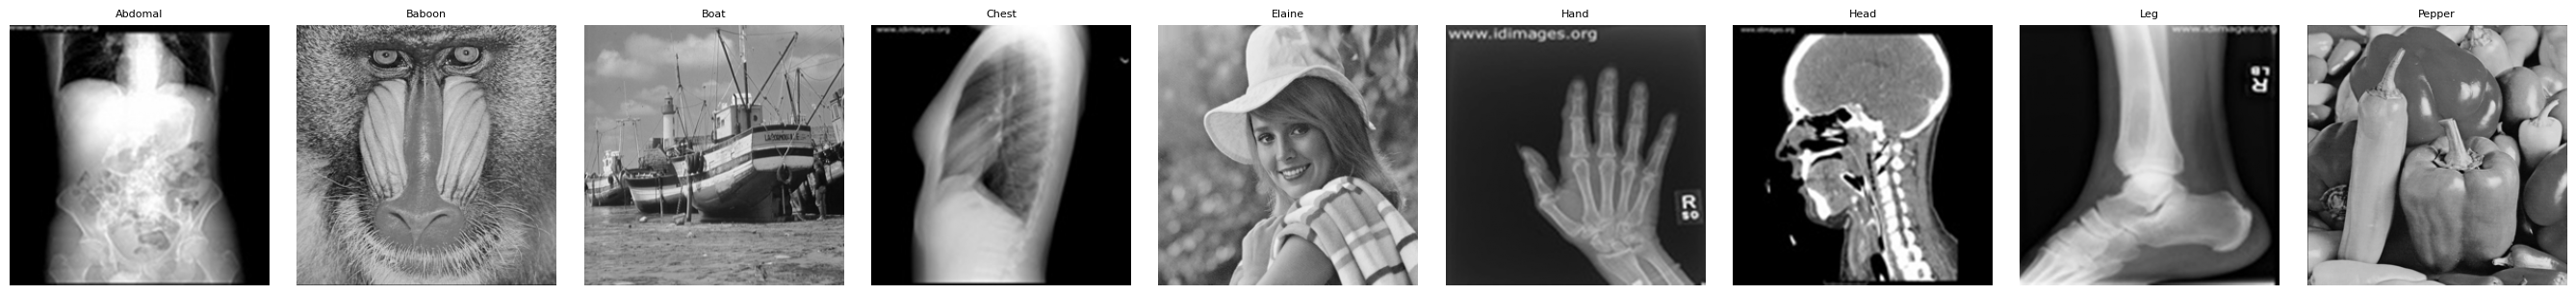


Default cover_img: Abdomal


In [ ]:
# STEP 1 — Load semua gambar dari Google Drive

from google.colab import drive
import gdown

# Mount Google Drive
drive.mount('/content/drive')

# ── Opsi A: langsung pakai path Drive (jika folder sudah ada di My Drive) ──
# dataset_path = '/content/drive/MyDrive/Dataset'

# ── Opsi B: download folder dari link Drive ke /content/Dataset ──
folder_id   = '1t7Zx_splrRJRN7FOoj-Y-mFD7GLjVD10'
dataset_path = '/content/Dataset'

os.makedirs(dataset_path, exist_ok=True)
gdown.download_folder(
    id=folder_id,
    output=dataset_path,
    quiet=False,
    use_cookies=False
)

# ── Load gambar seperti semula ──
def load_grayscale(img_path, size=(256, 256)):
    img = Image.open(img_path).convert('L').resize(size)
    return np.array(img, dtype=np.int32)

image_files = sorted(os.listdir(dataset_path))
images = {}

for fname in image_files:
    if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.tiff', '.tif')):
        path = os.path.join(dataset_path, fname)
        img  = load_grayscale(path)
        name = fname.split('.')[0]
        images[name] = img
        print(f'✅ {fname:20s} | Shape: {img.shape} | Min/Max: {img.min()}/{img.max()}')

print(f'\nTotal gambar loaded: {len(images)}')

# Tampilkan semua gambar
n_imgs = len(images)
fig, axes = plt.subplots(1, n_imgs, figsize=(3*n_imgs, 3))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Set cover_img default untuk demo STEP 6-8
cover_img = images[list(images.keys())[0]]
print(f'\nDefault cover_img: {list(images.keys())[0]}')

In [ ]:
# STEP 2 — Input secret bits

secret_message = input('\nMasukkan pesan rahasia (teks): ')
secret_bits    = [int(b) for b in ''.join(format(ord(c), '08b') for c in secret_message)]
n_bits         = len(secret_bits)

print(f'Pesan            : {secret_message}')
print(f'Jumlah bit       : {n_bits}')
print(f'Bit (10 pertama) : {secret_bits[:10]} ...')

# Generate bits full 100kb untuk evaluasi STEP 9
max_bits         = 100 * 1000 * 8
secret_bits_full = (secret_bits * (max_bits // len(secret_bits) + 1))[:max_bits]
print(f'\nBits full untuk evaluasi: {len(secret_bits_full)} bit ({len(secret_bits_full)//8000} kb)')



Masukkan pesan rahasia (teks): embedding adalah teknik untuk merepresentasikan data (seperti teks, kata, atau gambar) ke dalam bentuk deretan angka (vektor) di ruang berdimensi tinggi.
Pesan            : embedding adalah teknik untuk merepresentasikan data (seperti teks, kata, atau gambar) ke dalam bentuk deretan angka (vektor) di ruang berdimensi tinggi.
Jumlah bit       : 1224
Bit (10 pertama) : [0, 1, 1, 0, 0, 1, 0, 1, 0, 1] ...

Bits full untuk evaluasi: 800000 bit (100 kb)


In [ ]:
# STEP 3 — Fungsi Embedding (kondisi: d(i,j) = 0)
def embed(cover, bits):
    N, M       = cover.shape
    stego      = cover.copy().astype(np.int32)
    key_matrix = np.zeros((N, M), dtype=np.int32)
    median_map = np.zeros((N, M), dtype=np.float64)
    bit_index  = 0
    BLOCK      = 5

    for i in range(0, N - BLOCK + 1, BLOCK):
        for j in range(0, M - BLOCK + 1, BLOCK):
            for row in range(BLOCK):
                pi        = i + row
                row_block = cover[pi, j:j+BLOCK]
                median    = np.median(row_block)

                for col in range(BLOCK):
                    pj = j + col
                    median_map[pi][pj] = median
                    d = cover[pi][pj] - median  # d(i,j) = p(i,j) - Med(B)

                    if d == 0 and bit_index < len(bits):
                        bit = bits[bit_index]

                        # FIX: skip jika pixel=255 dan bit=1 (akan overflow ke 256)
                        if int(median) == 255 and bit == 1:
                            stego[pi][pj]      = cover[pi][pj]
                            key_matrix[pi][pj] = 0
                            continue  # lewati, jangan increment bit_index

                        stego[pi][pj]      = int(median) + bit
                        key_matrix[pi][pj] = 1
                        bit_index         += 1
                    else:
                        # NO → pixel tidak berubah
                        stego[pi][pj]      = cover[pi][pj]
                        key_matrix[pi][pj] = 0  # posisi tidak disisip bit

    print(f'\n[Embedding] Total posisi embedding : {np.sum(key_matrix == 1)}')
    print(f'[Embedding] Bit berhasil disisip    : {bit_index} dari {len(bits)}')
    if bit_index < len(bits):
        print(f'[PERINGATAN] Kapasitas tidak cukup! {len(bits)-bit_index} bit tidak tersimpan.')

    return stego, key_matrix, median_map

In [ ]:
# STEP 4 — Fungsi Ekstraksi (kondisi: d(i,j) = 0)
def extract(stego, key_matrix, median_map, n_bits):
    N, M        = stego.shape
    original    = stego.copy().astype(np.int32)
    secret_bits = []
    BLOCK       = 5

    for i in range(0, N - BLOCK + 1, BLOCK):
        for j in range(0, M - BLOCK + 1, BLOCK):
            for row in range(BLOCK):
                pi = i + row
                for col in range(BLOCK):
                    pj     = j + col
                    median = median_map[pi][pj]

                    if key_matrix[pi][pj] == 1:
                        # Ekstrak bit: stego = median + bit → bit = stego - median
                        bit = int(stego[pi][pj]) - int(median)
                        bit = max(0, min(1, bit))  # pastikan 0 atau 1
                        secret_bits.append(bit)

                        # Restore pixel → kembalikan ke median (karena d=0)
                        original[pi][pj] = int(median)
                    else:
                        original[pi][pj] = stego[pi][pj]

    secret_bits = secret_bits[:n_bits]
    return secret_bits, original

In [ ]:
# STEP 5 — Fungsi Evaluasi: PSNR, MSE, SSIM

def hitung_psnr(original, stego):
    mse = np.mean((original.astype(np.float64) - stego.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * math.log10((255 ** 2) / mse)

def hitung_mse(original, stego):
    return np.mean((original.astype(np.float64) - stego.astype(np.float64)) ** 2)

def hitung_ssim(original, stego):
    return ssim_func(original.astype(np.float64),
                     stego.astype(np.float64),
                     data_range=255)

print('✅ Fungsi PSNR, MSE, SSIM siap.')


✅ Fungsi PSNR, MSE, SSIM siap.


In [ ]:
# STEP 6 — Jalankan Embedding (demo 1 gambar)

# Ganti nama gambar sesuai keinginan
cover_img = images['Baboon']

stego_img, key_matrix, median_map = embed(cover_img, secret_bits)
stego_img = np.clip(stego_img, 0, 255).astype(np.uint8)

psnr_val = hitung_psnr(cover_img, stego_img)
mse_val  = hitung_mse(cover_img, stego_img)
ssim_val = hitung_ssim(cover_img, stego_img)

print(f'\n[PSNR] : {psnr_val:.2f} dB')
print(f'[MSE]  : {mse_val:.4f}')
print(f'[SSIM] : {ssim_val:.4f}')

if psnr_val >= 50:
    print('[Kualitas] Sangat baik — perubahan tidak terlihat mata')
elif psnr_val >= 40:
    print('[Kualitas] Baik')
elif psnr_val >= 30:
    print('[Kualitas] Cukup')
else:
    print('[Kualitas] Buruk')



[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[PSNR] : 68.85 dB
[MSE]  : 0.0085
[SSIM] : 1.0000
[Kualitas] Sangat baik — perubahan tidak terlihat mata


In [ ]:
# STEP 7 — Jalankan Ekstraksi (demo 1 gambar)

secret_bits_extracted, restored_img = extract(stego_img, key_matrix, median_map, n_bits)
restored_img = np.clip(restored_img, 0, 255).astype(np.uint8)

print(f'Ekstraksi selesai.')
print(f'Bit terekstrak   : {len(secret_bits_extracted)}')
print(f'Bit (10 pertama) : {secret_bits_extracted[:10]}')

match = all(a == b for a, b in zip(secret_bits_extracted, secret_bits))
print(f'\n[Verifikasi] Bit cocok dengan asli: {match}')

# Decode pesan — gunakan tepat n_bits saja
chars = []
bits_to_decode = secret_bits_extracted[:n_bits]  # ← batasi tepat n_bits
for i in range(0, len(bits_to_decode) - 7, 8):
    byte = bits_to_decode[i:i+8]
    if len(byte) == 8 and all(b in (0, 1) for b in byte):
        chars.append(chr(int(''.join(map(str, byte)), 2)))

recovered_message = ''.join(chars)
print(f'[Pesan terpulihkan]: {recovered_message}')

Ekstraksi selesai.
Bit terekstrak   : 1224
Bit (10 pertama) : [0, 1, 1, 0, 0, 1, 0, 1, 0, 1]

[Verifikasi] Bit cocok dengan asli: True
[Pesan terpulihkan]: embedding adalah teknik untuk merepresentasikan data (seperti teks, kata, atau gambar) ke dalam bentuk deretan angka (vektor) di ruang berdimensi tinggi.



[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


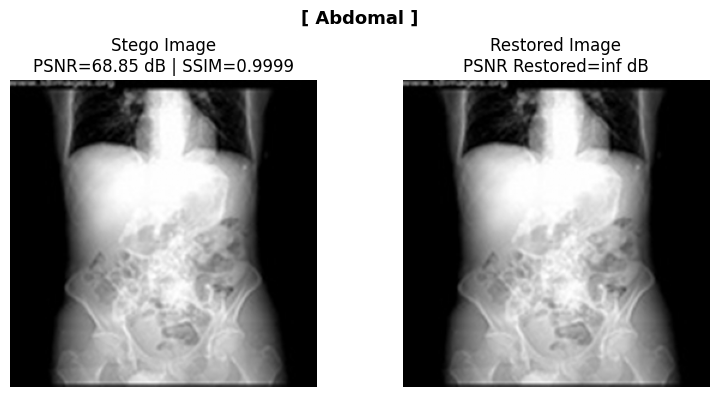

[Abdomal] PSNR: 68.85 dB | SSIM: 0.9999 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


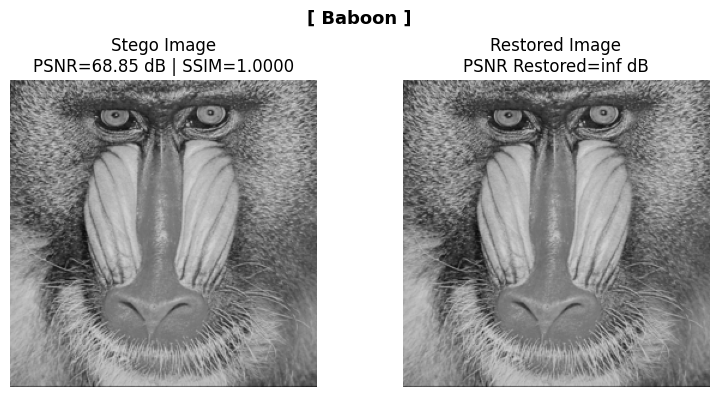

[Baboon] PSNR: 68.85 dB | SSIM: 1.0000 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


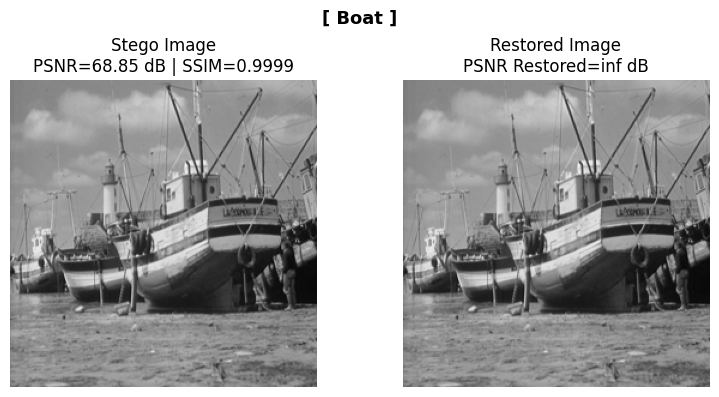

[Boat] PSNR: 68.85 dB | SSIM: 0.9999 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


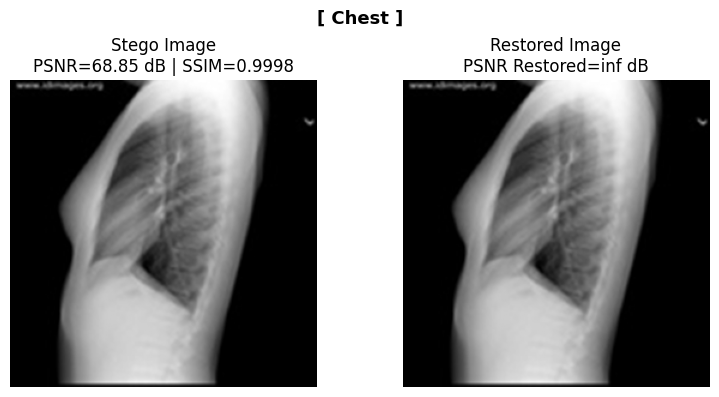

[Chest] PSNR: 68.85 dB | SSIM: 0.9998 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


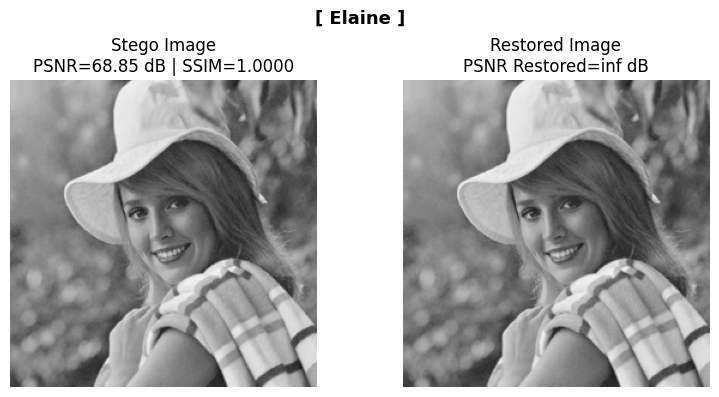

[Elaine] PSNR: 68.85 dB | SSIM: 1.0000 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


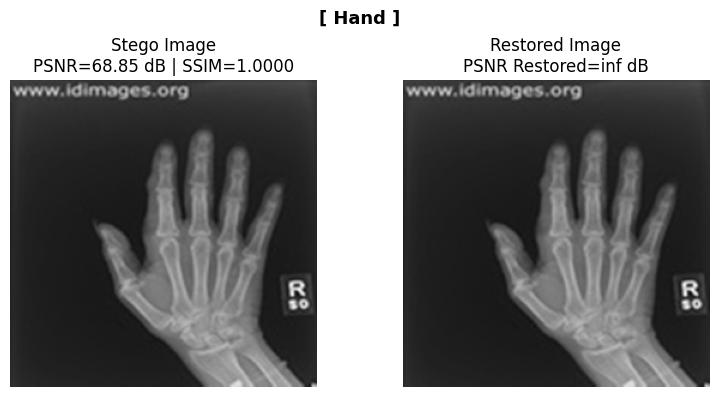

[Hand] PSNR: 68.85 dB | SSIM: 1.0000 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


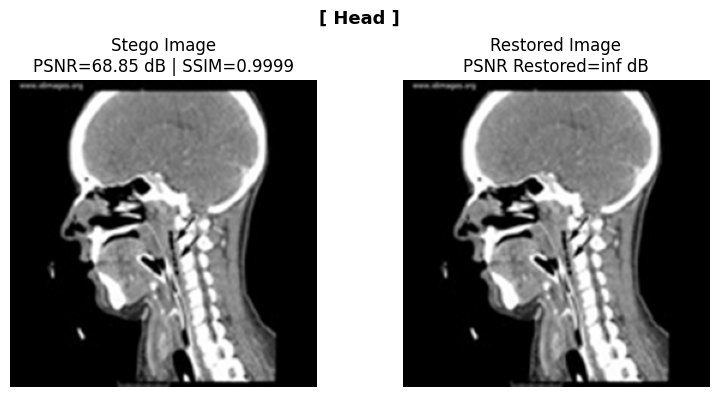

[Head] PSNR: 68.85 dB | SSIM: 0.9999 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


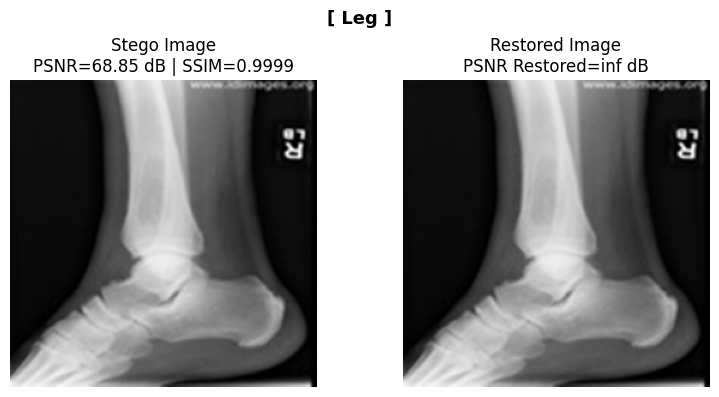

[Leg] PSNR: 68.85 dB | SSIM: 0.9999 | PSNR Restored: inf dB


[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224


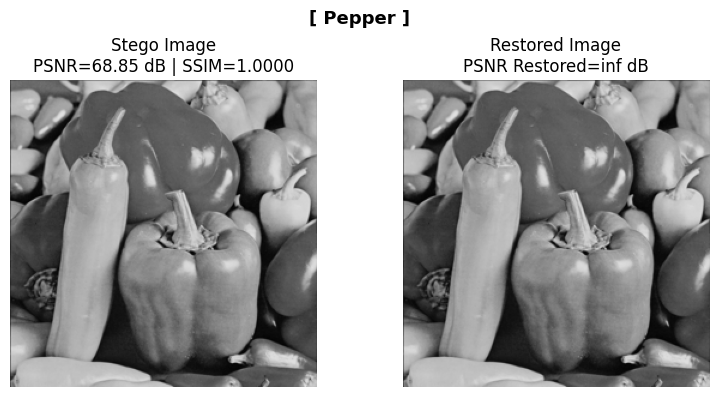

[Pepper] PSNR: 68.85 dB | SSIM: 1.0000 | PSNR Restored: inf dB



In [ ]:
# STEP 8 — Visualisasi Hasil Semua Gambar (Stego & Restored)

for img_name, cover in images.items():
    # Embedding
    stego_test, key_test, median_test = embed(cover, secret_bits)
    stego_test   = np.clip(stego_test, 0, 255).astype(np.uint8)

    # Ekstraksi
    _, restored_test = extract(stego_test, key_test, median_test, n_bits)
    restored_test    = np.clip(restored_test, 0, 255).astype(np.uint8)

    # Metrik
    psnr          = hitung_psnr(cover, stego_test)
    ssim          = hitung_ssim(cover, stego_test)
    psnr_restored = hitung_psnr(cover, restored_test)

    # Plot — hanya 2 gambar: Stego & Restored
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'[ {img_name} ]', fontsize=13, fontweight='bold')

    axes[0].imshow(stego_test, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Stego Image\nPSNR={psnr:.2f} dB | SSIM={ssim:.4f}')
    axes[0].axis('off')

    axes[1].imshow(restored_test, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'Restored Image\nPSNR Restored={psnr_restored:.2f} dB')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'[{img_name}] PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f} | PSNR Restored: {psnr_restored:.2f} dB\n')

In [ ]:
# STEP 9 — Evaluasi semua gambar (dinamis sesuai kapasitas)

all_psnr    = {}
all_ssim    = {}
all_sizes   = {}

for img_name, cover in images.items():
    # Hitung kapasitas maksimal gambar
    _, key_test, _ = embed(cover, secret_bits_full)
    max_cap = int(np.sum(key_test == 1))

    # Bagi jadi 10 titik evaluasi dari 10% sampai 100% kapasitas
    sizes_bits = [max(1, int(max_cap * p / 10)) for p in range(1, 11)]
    sizes_kb   = [round(s / 8000, 2) for s in sizes_bits]

    psnr_row = []
    ssim_row = []
    print(f'\n📷 {img_name} | Kapasitas max: {max_cap} bit ({max_cap/8000:.2f} kb)')

    for n, kb in zip(sizes_bits, sizes_kb):
        bits_test        = secret_bits_full[:n]
        stego_test, _, _ = embed(cover, bits_test)
        stego_test       = np.clip(stego_test, 0, 255).astype(np.uint8)

        psnr = hitung_psnr(cover, stego_test)
        ssim = hitung_ssim(cover, stego_test)

        psnr_row.append(round(psnr, 3))
        ssim_row.append(round(ssim, 4))
        print(f'  {kb:>5} kb ({n:>6} bit) | PSNR: {psnr:.3f} dB | SSIM: {ssim:.4f}')

    all_psnr[img_name]  = psnr_row
    all_ssim[img_name]  = ssim_row
    all_sizes[img_name] = sizes_kb

# Tampilkan Tabel Hasil
pct_labels = ['10%','20%','30%','40%','50%','60%','70%','80%','90%','100%']

df_psnr_clean = pd.DataFrame(
    {img: vals[:10] for img, vals in all_psnr.items()},
    index=pct_labels
).T

df_ssim_clean = pd.DataFrame(
    {img: vals[:10] for img, vals in all_ssim.items()},
    index=pct_labels
).T

print('\n=== TABLE I — PSNR (dB) ===')
print(df_psnr_clean.to_string())

print('\n=== TABLE II — SSIM ===')
print(df_ssim_clean.to_string())

print('\n=== KAPASITAS EMBEDDING ===')
for img_name, sizes in all_sizes.items():
    print(f'{img_name:12s} : max {sizes[9]:.2f} kb | 10%={sizes[0]:.2f} kb → 100%={sizes[9]:.2f} kb')



[Embedding] Total posisi embedding : 30756
[Embedding] Bit berhasil disisip    : 30756 dari 800000
[PERINGATAN] Kapasitas tidak cukup! 769244 bit tidak tersimpan.

📷 Abdomal | Kapasitas max: 30756 bit (3.84 kb)

[Embedding] Total posisi embedding : 3075
[Embedding] Bit berhasil disisip    : 3075 dari 3075
   0.38 kb (  3075 bit) | PSNR: 64.853 dB | SSIM: 0.9994

[Embedding] Total posisi embedding : 6151
[Embedding] Bit berhasil disisip    : 6151 dari 6151
   0.77 kb (  6151 bit) | PSNR: 61.840 dB | SSIM: 0.9984

[Embedding] Total posisi embedding : 9226
[Embedding] Bit berhasil disisip    : 9226 dari 9226
   1.15 kb (  9226 bit) | PSNR: 60.081 dB | SSIM: 0.9975

[Embedding] Total posisi embedding : 12302
[Embedding] Bit berhasil disisip    : 12302 dari 12302
   1.54 kb ( 12302 bit) | PSNR: 58.829 dB | SSIM: 0.9966

[Embedding] Total posisi embedding : 15378
[Embedding] Bit berhasil disisip    : 15378 dari 15378
   1.92 kb ( 15378 bit) | PSNR: 57.863 dB | SSIM: 0.9954

[Embedding] Tota

In [ ]:
# STEP 10 — Evaluasi dengan File Payload dari Drive
import os
import gdown

# Download folder Payload dari Google Drive
payload_folder_id = '11pO1NSlq33CPHcX-M287MTSqllAQHrYO'
payload_path      = '/content/Payload'

os.makedirs(payload_path, exist_ok=True)
gdown.download_folder(
    id=payload_folder_id,
    output=payload_path,
    quiet=False,
    use_cookies=False
)

print(f'\nFile dalam folder Payload:')
for f in sorted(os.listdir(payload_path)):
    print(f'  {f}')

Retrieving folder contents


Processing file 1oy23aAAgcVH60hzPAdBFafa4pf4Uxcdd random-binary_1Kb.txt
Processing file 17eVXh9oJ2ifSG3bAeoak-rhxdeZZK-ps random-binary_10Kb.txt
Processing file 1MHTUVuceR8i08zvFKLDxNXANbn3tSbUK random-binary_20Kb.txt
Processing file 1_kcua5CArN0jS_I-fWge66bLIfvzPgXM random-binary_30Kb.txt
Processing file 1wdXhwFBpf3C3yF7wZT9-EK_qJHHZOH7s random-binary_40Kb.txt
Processing file 166dvijpxS_g9p7DYR1qOnDtwKTsl2N_s random-binary_50Kb.txt
Processing file 1XXFsjabnw-thIp-1cL8v_6fNWSAV-LBZ random-binary_60Kb.txt
Processing file 1obKOWI0k-XQYuSMSB8g-TPDJhU461FIW random-binary_70Kb.txt
Processing file 1D-0bAwrIX2iID7H_Gajc0G5rYny2pgme random-binary_80Kb.txt
Processing file 1byM4mKKaHucqb0-XNaVDMGwDnEsDFpoa random-binary_90Kb.txt
Processing file 1kP19qNAh-I9s7RyY2CHYxWaKNfYTAxfk random-binary_100Kb.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1oy23aAAgcVH60hzPAdBFafa4pf4Uxcdd
To: /content/Payload/random-binary_1Kb.txt
100%|██████████| 2.00k/2.00k [00:00<00:00, 8.14MB/s]
Downloading...
From: https://drive.google.com/uc?id=17eVXh9oJ2ifSG3bAeoak-rhxdeZZK-ps
To: /content/Payload/random-binary_10Kb.txt
100%|██████████| 20.0k/20.0k [00:00<00:00, 36.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MHTUVuceR8i08zvFKLDxNXANbn3tSbUK
To: /content/Payload/random-binary_20Kb.txt
100%|██████████| 40.0k/40.0k [00:00<00:00, 13.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_kcua5CArN0jS_I-fWge66bLIfvzPgXM
To: /content/Payload/random-binary_30Kb.txt
100%|██████████| 60.0k/60.0k [00:00<00:00, 2.48MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wdXhwFBpf3C3yF7wZT9-EK_qJHHZOH7s
To: /content/Payload/random-binary_40Kb.txt
100%|██████████| 80.0k/80.0k [00:0


File dalam folder Payload:
  random-binary_100Kb.txt
  random-binary_10Kb.txt
  random-binary_1Kb.txt
  random-binary_20Kb.txt
  random-binary_30Kb.txt
  random-binary_40Kb.txt
  random-binary_50Kb.txt
  random-binary_60Kb.txt
  random-binary_70Kb.txt
  random-binary_80Kb.txt
  random-binary_90Kb.txt



Download completed


In [ ]:
# STEP 11 — Load Payload & Evaluasi

payload_files = {
    '1 kb'  : 'random-binary_1Kb.txt',
    '10 kb' : 'random-binary_10Kb.txt',
    '20 kb' : 'random-binary_20Kb.txt',
    '30 kb' : 'random-binary_30Kb.txt',
    '40 kb' : 'random-binary_40Kb.txt',
    '50 kb' : 'random-binary_50Kb.txt',
    '60 kb' : 'random-binary_60Kb.txt',
    '70 kb' : 'random-binary_70Kb.txt',
    '80 kb' : 'random-binary_80Kb.txt',
    '90 kb' : 'random-binary_90Kb.txt',
    '100 kb': 'random-binary_100Kb.txt',
}

def load_payload(filepath):
    with open(filepath, 'r') as f:
        content = f.read()
    bits = [int(c) for c in content if c in ('0', '1')]
    return bits

# Load semua payload
payloads = {}
for label, fname in payload_files.items():
    path = os.path.join(payload_path, fname)
    if os.path.exists(path):
        bits = load_payload(path)
        payloads[label] = bits
        print(f'✅ {label:>6} | {len(bits):>8} bit ({len(bits)/8000:.2f} kb)')
    else:
        print(f'❌ {label:>6} | File tidak ditemukan: {fname}')

print(f'\nTotal payload loaded: {len(payloads)}')

# Evaluasi semua gambar × semua payload
all_psnr_p   = {}
all_ssim_p   = {}
all_status_p = {}

for img_name, cover in images.items():
    psnr_row   = []
    ssim_row   = []
    status_row = []

    _, key_cap, _ = embed(cover, [0] * 800000)
    max_cap_bits  = int(np.sum(key_cap == 1))
    max_cap_kb    = max_cap_bits / 8000

    print(f'\n📷 {img_name} | Kapasitas max: {max_cap_bits} bit ({max_cap_kb:.2f} kb)')
    print(f'{"Payload":>8} | {"Bit Diminta":>12} | {"Bit Tersisip":>12} | {"Status":<22} | {"PSNR (dB)":>10} | {"SSIM":>8}')
    print('-' * 85)

    for label, bits in payloads.items():
        n_req = len(bits)

        if n_req <= max_cap_bits:
            status     = 'OK ✅'
            bits_embed = bits
        else:
            status     = 'MELEBIHI KAPASITAS ⚠️'
            bits_embed = bits[:max_cap_bits]

        stego_test, _, _ = embed(cover, bits_embed)
        stego_test = np.clip(stego_test, 0, 255).astype(np.uint8)

        psnr = hitung_psnr(cover, stego_test)
        ssim = hitung_ssim(cover, stego_test)

        psnr_row.append(round(psnr, 3))
        ssim_row.append(round(ssim, 4))
        status_row.append(status)

        print(f'{label:>8} | {n_req:>12,} | {len(bits_embed):>12,} | {status:<22} | {psnr:>10.3f} | {ssim:>8.4f}')

    all_psnr_p[img_name]   = psnr_row
    all_ssim_p[img_name]   = ssim_row
    all_status_p[img_name] = status_row

# Tabel Ringkasan
cols = list(payloads.keys())

df_psnr_p = pd.DataFrame(all_psnr_p, index=cols).T
df_ssim_p = pd.DataFrame(all_ssim_p, index=cols).T

print('\n=== TABLE I — PSNR (dB) ===')
print(df_psnr_p.to_string())

print('\n=== TABLE II — SSIM ===')
print(df_ssim_p.to_string())

print('\n=== TABLE III — STATUS KAPASITAS ===')
df_status = pd.DataFrame(all_status_p, index=cols).T
print(df_status.to_string())

✅   1 kb |     1000 bit (0.12 kb)
✅  10 kb |    10000 bit (1.25 kb)
✅  20 kb |    20000 bit (2.50 kb)
✅  30 kb |    30000 bit (3.75 kb)
✅  40 kb |    40000 bit (5.00 kb)
✅  50 kb |    50000 bit (6.25 kb)
✅  60 kb |    60000 bit (7.50 kb)
✅  70 kb |    70000 bit (8.75 kb)
✅  80 kb |    80000 bit (10.00 kb)
✅  90 kb |    90000 bit (11.25 kb)
✅ 100 kb |   100000 bit (12.50 kb)

Total payload loaded: 11

[Embedding] Total posisi embedding : 30897
[Embedding] Bit berhasil disisip    : 30897 dari 800000
[PERINGATAN] Kapasitas tidak cukup! 769103 bit tidak tersimpan.

📷 Abdomal | Kapasitas max: 30897 bit (3.86 kb)
 Payload |  Bit Diminta | Bit Tersisip | Status                 |  PSNR (dB) |     SSIM
-------------------------------------------------------------------------------------

[Embedding] Total posisi embedding : 1000
[Embedding] Bit berhasil disisip    : 1000 dari 1000
    1 kb |        1,000 |        1,000 | OK ✅                   |     69.411 |   0.9999

[Embedding] Total posisi e

In [ ]:
# VALIDASI PESAN — Extracted vs Embedded (semua gambar)

# Helper decode bits → teks
def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits) - 7, 8):
        byte = bits[i:i+8]
        try:
            chars.append(chr(int(''.join(map(str, byte)), 2)))
        except:
            chars.append('?')
    return ''.join(chars)

print("=" * 65)
print("VALIDASI AKHIR — Pesan Embedded vs Extracted (Semua Gambar)")
print("=" * 65)

import pandas as pd
rows = []
semua_ok = True
for img_name, cover in images.items():
    stego_v, key_v, median_v = embed(cover, secret_bits)
    stego_v = np.clip(stego_v, 0, 255).astype(np.uint8)
    ext_bits, _ = extract(stego_v, key_v, median_v, n_bits)

    n_cocok  = sum(a == b for a, b in zip(secret_bits, ext_bits))
    n_beda   = len(secret_bits) - n_cocok
    pct      = (n_cocok / len(secret_bits)) * 100
    BER      = n_beda / len(secret_bits)
    ext_text = bits_to_text(ext_bits)[:len(secret_message)]
    teks_ok  = ext_text == secret_message
    if not teks_ok: semua_ok = False

    rows.append({
        'Gambar'      : img_name,
        'Total Bit'   : len(secret_bits),
        'Bit Cocok'   : n_cocok,
        'Bit Beda'    : n_beda,
        'Akurasi (%)'  : f"{pct:.6f}",
        'BER'         : f"{BER:.8f}",
        'Teks Sama'   : '✅ Ya' if teks_ok else '❌ Tidak',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\n{'='*65}")
print(f"✅ KESIMPULAN: {'Semua gambar 100% — Pesan identik sempurna' if semua_ok else 'Ada gambar yang gagal'}")

VALIDASI AKHIR — Pesan Embedded vs Extracted (Semua Gambar)

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224

[Embedding] Total posisi embedding : 1224
[Embedding] Bit berhasil disisip    : 1224 dari 1224
 Gambar  Total Bit  Bit Cocok  Bit Beda Akurasi (%)        BER Teks Sama
Abd